In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: crunchygremlin
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:04<00:00, 166MB/s] 


import torch: This line imports the main PyTorch library. PyTorch is an open-source machine learning framework that helps build and train neural networks.

from torch import nn: This imports the nn module from PyTorch, which is crucial for defining neural network layers (like convolutional layers, linear layers, etc.) and models.

from torch.optim import Adam: This imports Adam, which is a very popular optimization algorithm. Optimizers are used to adjust the model's parameters during training to minimize the loss function.

from torchvision.transforms import transforms: torchvision.transforms contains common image transformations, like resizing, cropping, and converting images to PyTorch tensors, which are essential for preparing image data for neural networks.

from torch.utils.data import Dataset, DataLoader: These are fundamental classes for handling data in PyTorch. Dataset provides an interface to access individual data samples (like an image and its label), and DataLoader wraps a Dataset to provide an iterable over the dataset, handling batching, shuffling, and multi-processing.

from sklearn.preprocessing import LabelEncoder: This imports LabelEncoder from scikit-learn, which is used to convert categorical labels (like 'cat', 'dog', 'wild') into numerical labels (e.g., 0, 1, 2) that machine learning models can understand.

import matplotlib.pyplot as plt: This imports matplotlib for creating static, interactive, and animated visualizations in Python, which is often used to plot training progress or display images.

from PIL import Image: This imports the Image module from the Pillow library (a friendly fork of PIL - Python Imaging Library). It's used for opening, manipulating, and saving many different image file formats.

import pandas as pd: This imports the pandas library, which is excellent for data manipulation and analysis, especially with tabular data (like the dataframes you'll use to store image paths and labels).

import numpy as np: This imports the numpy library, a foundational package for numerical computation in Python, especially for working with arrays and mathematical operations.

import os: This imports the os module, which provides a way to interact with the operating system, like listing directories or constructing file paths.

device = "cuda" if torch.cuda.is_available() else "cpu": This is a critical line for performance. It checks if a CUDA-enabled GPU is available on your system (torch.cuda.is_available()). If it is, the device variable is set to "cuda", meaning your model and data will be processed on the GPU (which is much faster for deep learning). Otherwise, it defaults to "cpu".

print(device): This simply prints out which device (GPU or CPU) PyTorch will be using for computations.

In [ ]:
import torch #main PyTorch library
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path","labels"])
print(data_df["labels"].unique())
data_df.head()

['dog' 'cat' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
1,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
2,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
3,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
4,/content/animal-faces/afhq/train/dog/pixabay_d...,dog


image_path = [] and labels = []: These lines initialize two empty lists. image_path will store the full file paths to each image, and labels will store the corresponding category (e.g., 'cat', 'dog', 'wild') for each image.

Nested for loops: This is the core part where you traverse your dataset's directory structure. Let's look at the structure:

for i in os.listdir("/content/animal-faces/afhq"): This loop iterates through the top-level folders inside /content/animal-faces/afhq. Based on the dataset, i would likely represent 'train' or 'val' (or 'test' if it were present). The executed output shows '/content/animal-faces/afhq/train/cat' etc., so i will iterate through 'train' and 'val' first, which then contain the actual label folders.
for label in os.listdir(f"/content/animal-faces/afhq/{i}"): This nested loop goes into each of those top-level folders (like 'train') and lists their contents. Here, label will pick up the actual animal categories like 'cat', 'wild', 'dog'.
for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"): This innermost loop dives into each animal category folder (e.g., /content/animal-faces/afhq/train/cat) and lists all the individual image filenames within it.
image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}"): For each image found, its full file path is constructed using an f-string and added to the image_path list.

labels.append(label): For each image, its corresponding category (e.g., 'cat') is added to the labels list.

After these loops complete, image_path will contain every image's full address, and labels will have the category for each of those images, in the same order.
data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path","labels"]): This line creates a pandas.DataFrame. zip(image_path, labels) pairs up each image path with its label. The pd.DataFrame() constructor then converts these pairs into a table with two columns named "image_path" and "labels". This DataFrame now holds all the information about your dataset in a structured, easy-to-use format.

print(data_df["labels"].unique()): This prints out all the unique values found in the "labels" column of your data_df. This is a quick way to confirm what categories of animals are present in your dataset (e.g., ['cat' 'wild' 'dog']).

data_df.head(): This displays the first 5 rows of your newly created data_df. It's a useful command to quickly inspect the structure and content of your DataFrame to ensure it was created correctly.

In [ ]:
#splitting your data_df into training, validation, and test datasets.
#creates the train dataset by randomly sampling 70% of the rows from your original data_df.

train = data_df.sample(frac = 0.7)
# 30% of the data (which were not included in train) are assigned to the test variable.
#This is done by dropping the indices that were selected for the train set from the original data_df.
test = data_df.drop(train.index)

#The test dataset (which currently holds 30% of the original data) is further split.
#This line randomly samples 50% of the current test dataset to create the val (validation) dataset.
#This means the validation set will contain 15% of the original data_df (0.5 * 0.3 = 0.15).

val = test.sample(frac = 0.5)

#The remaining 50% of the data from the previous test set (which was not included in val) is
#assigned back to the test variable.
#This final test set will also contain 15% of the original data_df.

test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [ ]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)

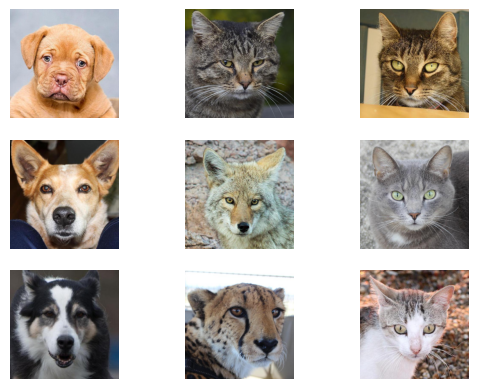

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")
    axarr[row,col].imshow(image)
    axarr[row,col].axis('off')

plt.show()


In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)

    self.pooling = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16),128)
    self.output = nn.Linear(128,len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) # -> (32, 128, 128)
    x = self.pooling(x) # -> (32, 64, 64)
    x = self.relu(x)

    x = self.conv2(x) # -> (64, 64, 64)
    x = self.pooling(x) # -> (64, 32, ,32)
    x = self.relu(x)

    x = self.conv3(x) # -> (128, 32, 32)
    x = self.pooling(x) # -> (128, 16, 16)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)
    return x


In [ ]:
model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [ ]:
criterion = nn.CrossEntropyLoss()
optimzer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimzer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimzer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__() * 100, 4))

  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round(total_acc_val/val_dataset.__len__() * 100, 4)}
          ''')



Epoch 1/10, Train Loss: 0.337 Train Accuracy: 80.3826
              Validation Loss: 0.0427 Validation Accuracy: 89.5868
          
Epoch 2/10, Train Loss: 0.1378 Train Accuracy: 92.8173
              Validation Loss: 0.0276 Validation Accuracy: 92.8926
          
Epoch 3/10, Train Loss: 0.0932 Train Accuracy: 95.5274
              Validation Loss: 0.0219 Validation Accuracy: 95.0413
          
Epoch 4/10, Train Loss: 0.0663 Train Accuracy: 96.5991
              Validation Loss: 0.0203 Validation Accuracy: 95.4132
          
Epoch 5/10, Train Loss: 0.0494 Train Accuracy: 97.6176
              Validation Loss: 0.0289 Validation Accuracy: 93.2231
          
Epoch 6/10, Train Loss: 0.0392 Train Accuracy: 98.0958
              Validation Loss: 0.0208 Validation Accuracy: 95.8678
          
Epoch 7/10, Train Loss: 0.0255 Train Accuracy: 98.7601
              Validation Loss: 0.0208 Validation Accuracy: 95.5785
          
Epoch 8/10, Train Loss: 0.0201 Train Accuracy: 99.0435
              V

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f'Accuracy Score is: {round(total_acc_test/test_dataset.__len__() *100, 4)} and Loss is {round(total_loss_test/1000, 4)}')


Accuracy Score is: 96.1141 and Loss is 0.0221


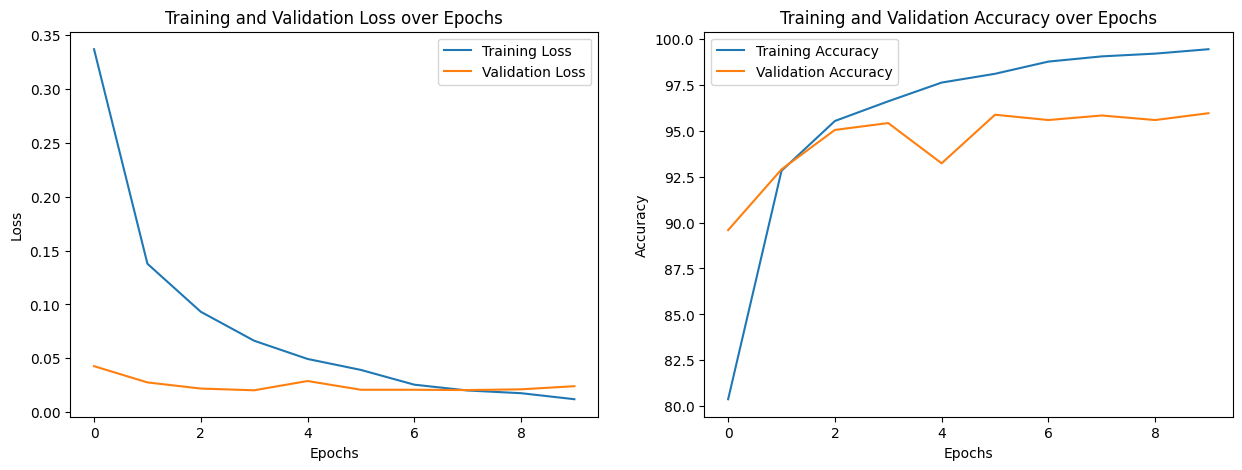

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

In [ ]:
#1 Read the image
#2 Transform using the transform object
#3 Predict through the moddel
#4 Inverse transform by label encoder

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)
  print(image.shape)
  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output]).item()


In [ ]:
predict_image("/content/wild_image.jpg")

torch.Size([3, 128, 128])


'wild'